In [21]:
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

(X_train,y_train),(X_test,y_test) = fashion_mnist.load_data()

class_labels = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']


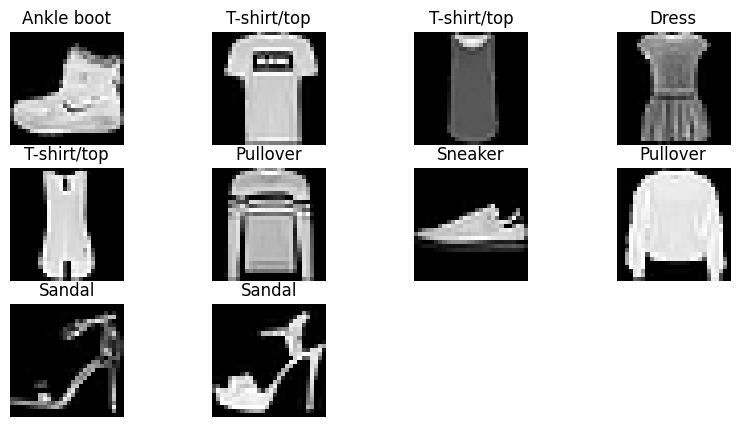

In [22]:
plt.figure(figsize=(10,5))
for x in range(10):
  plt.subplot(3,4,x+1)
  plt.imshow(X_train[x] , cmap='gray')
  plt.title(class_labels[y_train[x]])
  plt.axis('off')

plt.show()

In [23]:
X_train.astype(float)/255.0

y_train.astype(float)/255.0

array([0.03529412, 0.        , 0.        , ..., 0.01176471, 0.        ,
       0.01960784])

In [40]:
from tensorflow.keras.layers  import Conv2D , MaxPooling2D,Dense,Flatten,AveragePooling2D,Dropout
from tensorflow.keras.models import Sequential

cnn_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    AveragePooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(10,activation='softmax')
    ])

cnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy' , metrics=['accuracy'])

cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 5, 5, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history = cnn_model.fit(X_train,y_train ,epochs=10 , batch_size=64 , validation_split=0.1)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7975 - loss: 0.8004 - val_accuracy: 0.8585 - val_loss: 0.3743
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8599 - loss: 0.3839 - val_accuracy: 0.8767 - val_loss: 0.3370
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8758 - loss: 0.3369 - val_accuracy: 0.8808 - val_loss: 0.3255
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8878 - loss: 0.3048 - val_accuracy: 0.8865 - val_loss: 0.2935
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8946 - loss: 0.2820 - val_accuracy: 0.8930 - val_loss: 0.2935
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9007 - loss: 0.2672 - val_accuracy: 0.8992 - val_loss: 0.2679
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9058 - loss: 0.2530 - val_accuracy: 0.8978 - val_loss: 0.2679
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9125 - loss: 0.2329 - val_accuracy: 0.

In [42]:
train_loss , train_acc = cnn_model.evaluate(X_train , y_train)

test_loss , test_acc = cnn_model.evaluate(X_test,y_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9363 - loss: 0.1711
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9023 - loss: 0.3011


In [43]:
print("Training Accuracy : " , train_acc)
print("Training Loss : " ,train_loss)
print("Test Accuracy : " , test_acc)
print("Test Loss : " ,test_loss)

Training Accuracy :  0.9362833499908447
Training Loss :  0.17108134925365448
Test Accuracy :  0.9023000001907349
Test Loss :  0.30110567808151245


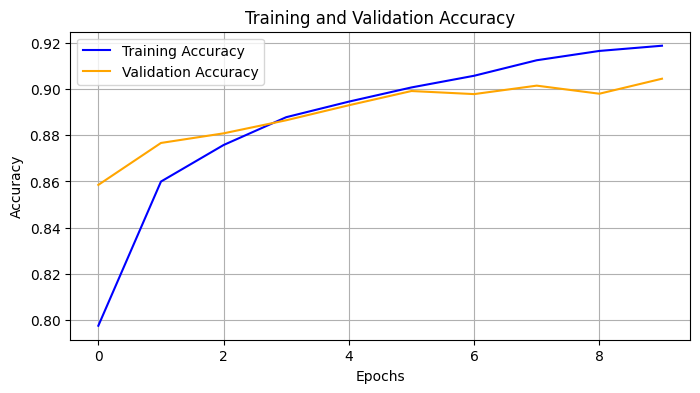

In [44]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred = cnn_model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


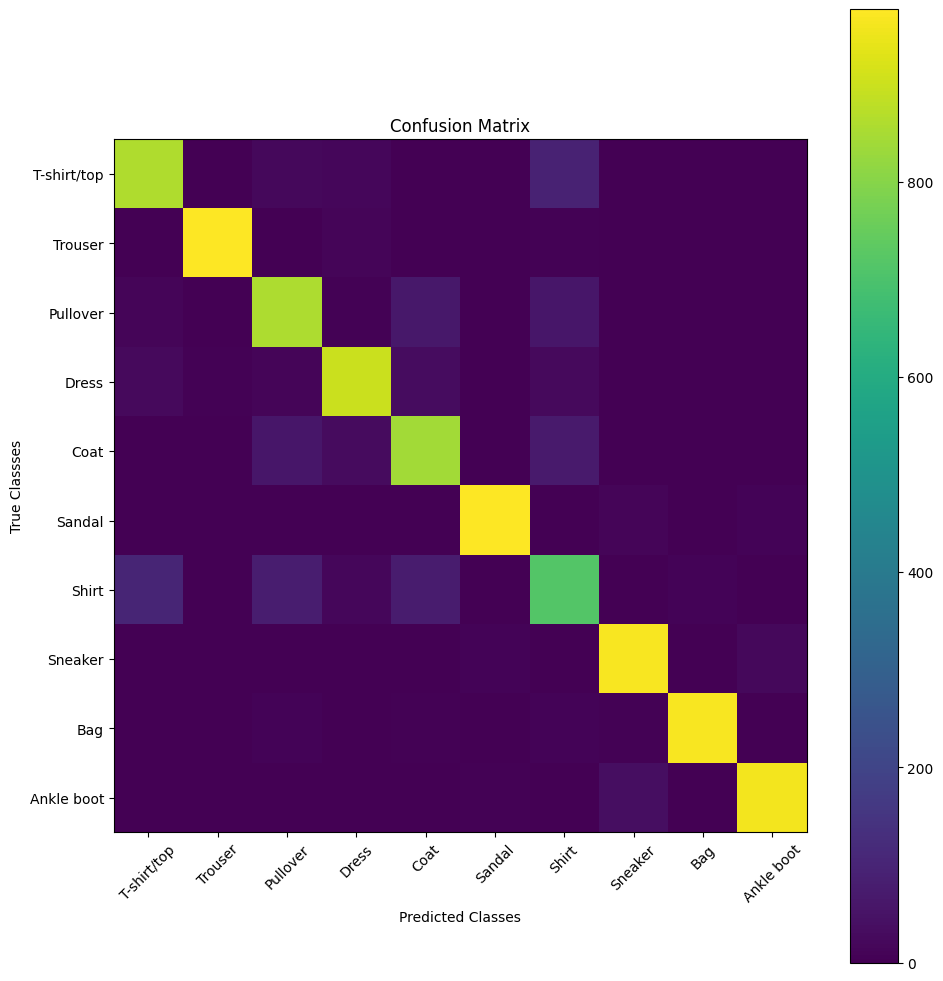

In [55]:

plt.figure(figsize=(10,10))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
num_classes = len(class_labels)
plt.xticks(np.arange(num_classes)  , class_labels , rotation = 45)
plt.yticks(np.arange(num_classes),class_labels)
plt.xlabel("Predicted Classes")
plt.ylabel("True Classses")
plt.tight_layout()
plt.show()

In [56]:
correct_pred = np.where(y_pred == y_test)[0]

incorrect_pred = np.where(y_pred != y_test)[0]

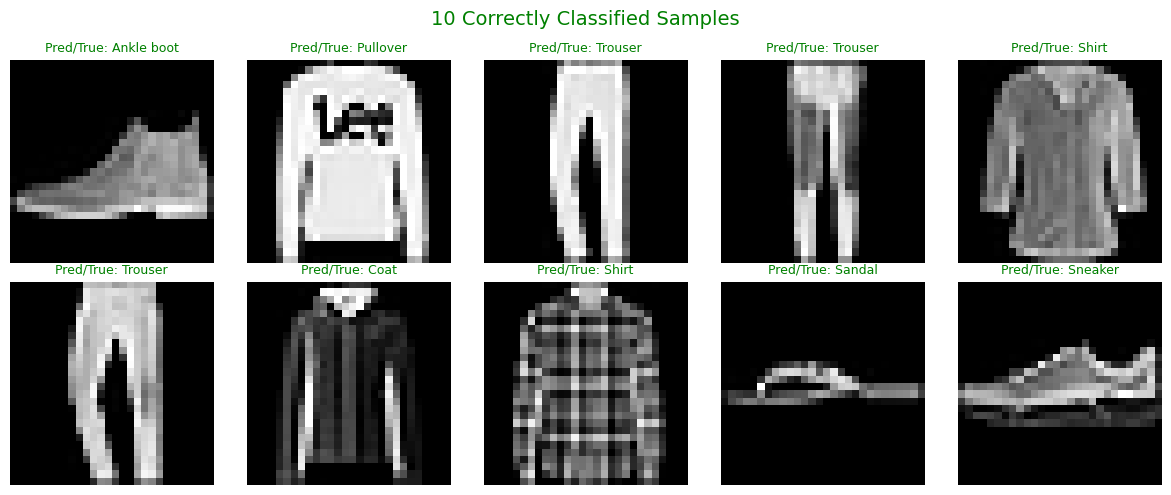

In [60]:
plt.figure(figsize=(12, 5))
plt.suptitle("10 Correctly Classified Samples", fontsize=14, color='green')
for i, idx in enumerate(correct_pred[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Pred/True: {class_labels[y_pred[idx]]}", color='green', fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()


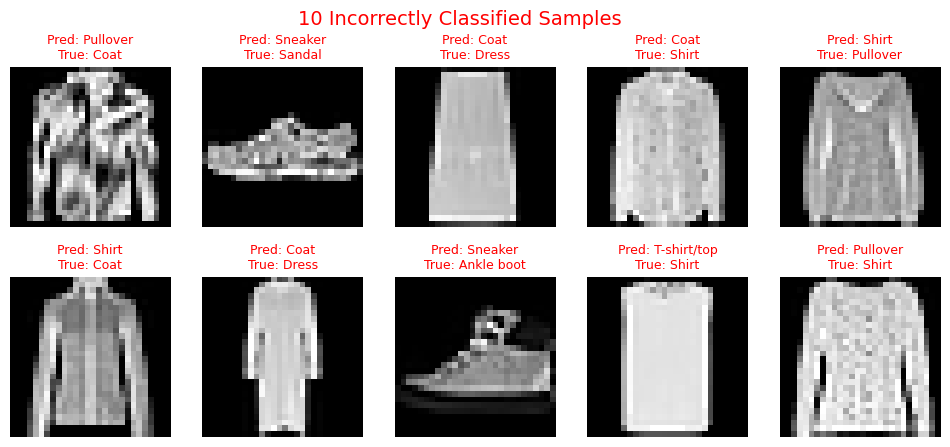

In [68]:
plt.figure(figsize=(12, 5))
plt.suptitle("10 Incorrectly Classified Samples", fontsize=14, color='red')
for i, idx in enumerate(incorrect_pred[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {class_labels[y_pred[idx]]}\nTrue: {class_labels[y_test[idx]]}", color='red', fontsize=9)
    plt.axis('off')

plt.show()